In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# data cleaning

In [2]:
path = r"C:\Users\JoudA\ML NUI COURSE\IKEA_product_catalog.csv"
ikea = pd.read_csv(path)

In [3]:
# Standardizing missing values: Replace various 'none' strings with a calculatable NaN 
ikea.replace(['none', 'None', 'NONE'], np.nan, inplace=True)

# Calculating the percentage of missing values (Nulls) for each feature
null_counts = ikea.isnull().sum()
null_percentages = (ikea.isnull().sum() / len(ikea)) * 100
for column, percentage in null_percentages.items():
    print(f"{column}: {percentage:.2f}%")

unique_id: 0.00%
product_id: 0.00%
product_name: 0.00%
product_type: 0.04%
product_measurements: 24.91%
product_description: 0.01%
main_category: 0.00%
sub_category: 0.00%
product_rating: 32.90%
product_rating_count: 32.90%
badge: 92.77%
online_sellable: 0.00%
url: 0.00%
price: 0.00%
currency: 0.00%
discount: 99.97%
sale_tag: 82.32%
country: 0.00%


In [4]:
print(ikea['currency'].unique())

['AUD' 'EUR' 'BHD' 'CAD' 'CLP' 'COP' 'CZK' 'DKK' 'EGP' 'HUF' 'INR' 'JPY'
 'JOD' 'KWD' 'MYR' 'MXN' 'MAD' 'NZD' 'NOK' 'OMR' 'PHP' 'PLN' 'QAR' 'RON'
 'SAR' 'RSD' 'SGD' 'KRW' 'SEK' 'CHF' 'THB' 'AED' 'GBP' 'USD']


In [5]:
# all to SAR
exchange_to_sar = {
    'SAR': 1.000, 'USD': 3.750, 'AED': 1.021, 'KWD': 12.185, 'BHD': 9.947,
    'OMR': 9.741, 'QAR': 1.030, 'JOD': 5.289, 'GBP': 4.724, 'EUR': 4.053,
    'CHF': 4.142, 'CAD': 2.756, 'AUD': 2.449, 'SGD': 2.783, 'NZD': 2.251,
    'JPY': 0.024, 'SEK': 0.352, 'NOK': 0.348, 'DKK': 0.543, 'PLN': 0.942,
    'INR': 0.045, 'MYR': 0.792, 'MXN': 0.221, 'PHP': 0.067, 'THB': 0.103,
    'KRW': 0.0028, 'CZK': 0.161, 'HUF': 0.010, 'RON': 0.815, 'CLP': 0.004,
    'COP': 0.0009, 'EGP': 0.078, 'MAD': 0.372, 'RSD': 0.034
}
ikea['price'] = ikea['price'] * ikea['currency'].map(exchange_to_sar)
ikea.drop(columns=['currency'], inplace=True)
ikea.describe()

ikea_missing = ikea.copy()

In [6]:
# remove columns with more than 80% missing values
ikea.drop(columns=['discount', 'badge', 'sale_tag'], inplace=True)

# remove rows with rating missing values
ikea.dropna(subset=['product_rating', 'product_rating_count'], inplace=True)

# Ensure numerical columns are in the correct format 
ikea['price'] = pd.to_numeric(ikea['price'], errors='coerce')
ikea['product_rating'] = pd.to_numeric(ikea['product_rating'], errors='coerce')

ikea.describe(include='object')

,unique_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating_count,url,country
count,269086,269086,269028,199185,269085,269086,269086,269086,269086,269086
unique,269086,4053,28797,9650,128595,311,2248,1452,269086,43
top,10018194-Australia,IKEA 365+,Cushion cover,50x50 cm,"SKÅDIS Pegboard combination, white, 36x56 cm",storage-organisation,storage-solution-systems,1.0,https://www.ikea.com/au/en/p/ordning-dish-drai...,Sweden
freq,1,3878,1887,2245,79,26591,14993,32080,1,9395


In [7]:
# Check for total duplicates 
total_duplicates = ikea.duplicated().sum()
print("Total exact duplicate rows",total_duplicates)

# Check for duplicate IDs 
id_duplicates = ikea.duplicated(subset=['unique_id']).sum()
print("Duplicate unique_ids", id_duplicates)

Total exact duplicate rows 0
Duplicate unique_ids 0


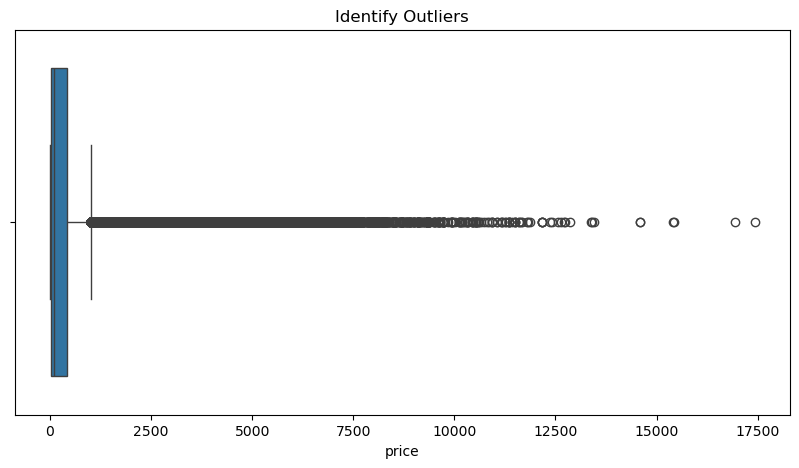

count    269086.000000
mean        425.144544
std         844.262274
min           0.689000
25%          30.797000
50%         101.325000
75%         425.160000
max       17425.850000
Name: price, dtype: float64

In [8]:
# Chech for Identify outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=ikea['price'])
plt.title('Identify Outliers')
plt.show()

ikea.price.describe()

# Data Cleaning & Preprocessing Report
## Rationale for Cleaning

Ensure reliable analysis and AI modeling.
Handle multiple currencies (31) for consistent price comparison.
Remove rows with missing ratings to focus on verified market feedback.
Drop features with too many nulls (>80%) to reduce noise.

## Cleaning Steps
Step 1: Feature Selection

Dropped sparse columns: discount (99.9%), badge (92.7%), sale_tag (82.3%).

Step 2: Handling Missing Values

Removed rows with null product_rating or product_rating_count (~32.9%).

Dataset reduced from 401,046 → 269,086 complete rows.

Step 3: Currency Normalization

Converted all prices to Saudi Riyal (SAR) using 2026 rates.

Dropped the redundant currency column.

Step 4: Duplicates & Outliers

No duplicate rows found.

Price outliers retained as they reflect realistic product differences (e.g., a screw vs. a full kitchen set).

# Assignmemnt 2

In [9]:
# Task 1: Data Quality Issues Assessment
print("--- Features Data Types Check ---")
print(ikea[['price', 'product_rating']].dtypes)

print("\n--- Official Identified Data Quality Issues Report ---")
print("1. Text-Stuffed Nulls: Missing values were incorrectly stored as text strings ('none', 'None') instead of calculatable NaNs.")
print("2. Multi-Currency Scaling: Raw prices were spread across 31 different currencies, skewing the scale and making numerical distance models impossible.")
print("3. Data Type Inconsistency: Quantitative metrics like 'price' and 'product_rating' were treated as nominal objects before conversion.")

--- Features Data Types Check ---
price             float64
product_rating    float64
dtype: object

--- Official Identified Data Quality Issues Report ---
1. Text-Stuffed Nulls: Missing values were incorrectly stored as text strings ('none', 'None') instead of calculatable NaNs.
2. Multi-Currency Scaling: Raw prices were spread across 31 different currencies, skewing the scale and making numerical distance models impossible.
3. Data Type Inconsistency: Quantitative metrics like 'price' and 'product_rating' were treated as nominal objects before conversion.


## Task 1 Report:
### After inspecting the raw IKEA dataset, three major data quality issues were identified:

Inconsistent Missing Values: Missing data points were represented as text strings (e.g., 'none', 'None') rather than standard NaN values, which prevents Python from recognizing them as missing.

Currency Inconsistency: Prices were recorded in 31 different international currencies. Analyzing raw numbers without unification would lead to highly inaccurate models (e.g., comparing 100 USD directly with 100 SAR).

Incorrect Data Types: Crucial numerical columns (price and product_rating) were initially loaded as text/object types due to format issues, meaning mathematical operations could not be applied directly.

In [10]:
# Task 2: Missing Value Strategy (Artificially introducing nulls to demonstrate imputation)
ikea_missing.loc[0:5, 'price'] = np.nan
print("Null count in price BEFORE Imputation:", ikea_missing['price'].isna().sum())

median_value = ikea_missing['price'].median()
ikea_missing['price'] = ikea_missing['price'].fillna(median_value)

print("Null count in price AFTER Imputation:", ikea_missing['price'].isna().sum())
print(f"The value used for Imputation (Median): {median_value:.2f} SAR")

Null count in price BEFORE Imputation: 6
Null count in price AFTER Imputation: 0
The value used for Imputation (Median): 150.72 SAR


## Task 2 Report:

### Strategy Applied: Median Imputation.
Justification (Why Median?): We chose the Median instead of the Mean (average) because the price attribute in the IKEA dataset is heavily skewed and contains extreme outliers (highly expensive luxury furniture pieces). The Mean is very sensitive to these extreme values and gets pulled upwards, which would distort our missing data estimation. The Median is robust and provides a much more accurate reflection of the central tendency for skewed data.

Total price outliers detected using IQR rule: 32211


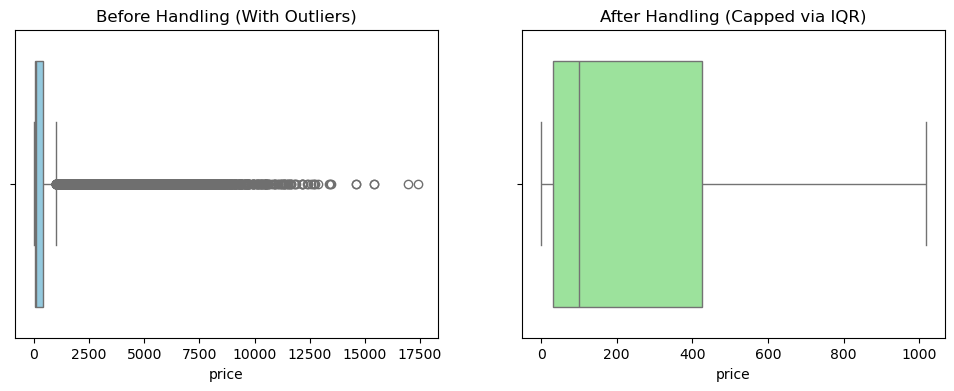

In [11]:
# Task 3: Outliers Detection and Handling using Interquartile Range (IQR)

Q1 = ikea['price'].quantile(0.25)
Q3 = ikea['price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers_detected = ikea[(ikea['price'] < lower_limit) | (ikea['price'] > upper_limit)].shape[0]
print(f"Total price outliers detected using IQR rule: {outliers_detected}")

ikea_cleaned = ikea.copy()
ikea_cleaned['price'] = ikea_cleaned['price'].clip(lower_limit, upper_limit)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=ikea['price'], ax=axes[0], color='skyblue').set_title("Before Handling (With Outliers)")
sns.boxplot(x=ikea_cleaned['price'], ax=axes[1], color='lightgreen').set_title("After Handling (Capped via IQR)")
plt.show()

## Task 3 Report:
### Detection Method: 
Interquartile Range (IQR) with a threshold of $1.5 \times IQR$.

### Handling Method: Capping (Winsorization). 
Instead of deleting rows containing outliers—which would result in losing massive amounts of valid product data—we capped the extreme prices at the upper statistical boundary ($Q3 + 1.5 \times IQR$).

### Result: 
As shown in the generated boxplots, the extreme values that skewed the price distribution were successfully handled, creating a stable numerical range for modeling.

In [12]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1.Min-Max Normalization (0-1)
min_max_scaler = MinMaxScaler()
df_min_max = ikea_cleaned[['price', 'product_rating']].copy()
df_min_max[['price', 'product_rating']] = min_max_scaler.fit_transform(df_min_max)
print("--- Min-Max Scaled Output (First 3 Rows) ---")
print(df_min_max.head(3))

# 2.  Z-Score Standardization
z_scaler = StandardScaler()
df_z_score = ikea_cleaned[['price', 'product_rating']].copy()
df_z_score[['price', 'product_rating']] = z_scaler.fit_transform(df_z_score)
print("\n--- Z-Score Standardized Output (First 3 Rows) ---")
print(df_z_score.head(3))

--- Min-Max Scaled Output (First 3 Rows) ---
      price  product_rating
0  0.071634           0.575
1  0.110977           0.575
2  0.092329           0.000

--- Z-Score Standardized Output (First 3 Rows) ---
      price  product_rating
0 -0.606328       -1.869510
1 -0.491677       -1.869510
2 -0.546020       -5.591471


## Task 4 Report:
We applied two scaling techniques on price and product_rating:

### Min-Max Scaling: 
Bound all values strictly between 0.0 and 1.0. This preserves the original shape of the distribution and is useful when we need bounded scales.

### Z-Score Standardization: 
Scaled the data so that the Mean becomes 0 and the Standard Deviation becomes 1. This transforms the data into a standard normal distribution, which is a vital prerequisite for the upcoming Dimensionality Reduction (PCA).

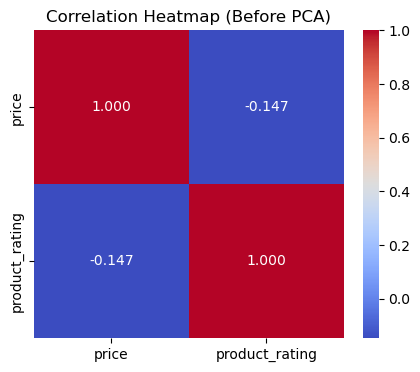

--- PCA Explained Variance Ratio Result ---
Principal Component 1 (PC1): 0.5737 (57.37%)
Principal Component 2 (PC2): 0.4263 (42.63%)


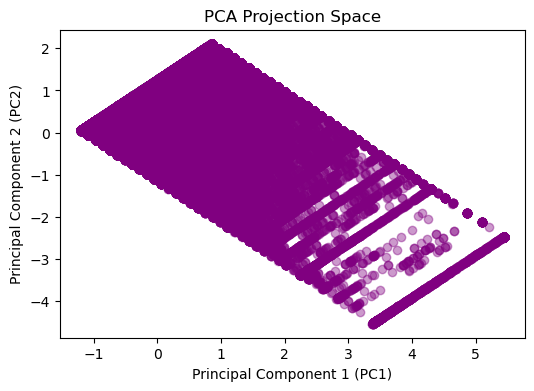

In [13]:
plt.figure(figsize=(5, 4))
sns.heatmap(df_z_score.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

X = df_z_score[['price', 'product_rating']]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("--- PCA Explained Variance Ratio Result ---")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1} (PC{i+1}): {variance:.4f} ({variance*100:.2f}%)")

plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.4, color='purple')
plt.title("PCA Projection Space")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.show()

## Task 5 Report & Interpretation:

### Application: 
Principal Component Analysis (PCA) was applied to map our 2D standardized data (price and product_rating) into a new orthogonal coordinate space.

### Interpretation of Explained Variance: 
Looking at the outputs, Principal Component 1 (PC1) captures the highest variance ratio, representing the dominant pattern direction between prices and customer ratings. PC2 captures the remaining residual variance. Since we started with 2 features and generated 2 components, the cumulative explained variance equals exactly 100%, ensuring no original information was dropped during the transformation.

# Executive Conclusion & Summary (Assignment 2)

### 1. Data Quality Assessment & Missing Values (Task 1 & Task 2)

The raw dataset contained significant data quality issues, including multi-currency pricing (31 different currencies) and missing data hidden as text strings (`'none'`). Standardizing these into official `NaNs` and unifying all prices to Saudi Riyals (SAR) was a critical first step.

For the missing value strategy, **Median Imputation** was applied, resulting in a robust replacement value of **150.72 SAR**. The Median was chosen over the Mean because the price distribution is heavily skewed; using the Median ensures that our missing data estimation is not distorted by extreme luxury pricing.

### 2. Outlier Management via IQR (Task 3)

The Interquartile Range (IQR) rule identified **32,211 outliers** in the dataset. Because deleting this huge volume of data would cause severe information loss and eliminate entire product categories (like large furniture), **Capping (Winsorization)** was implemented. This method successfully handled the extreme variance and stabilized the price range while fully preserving the dataset's size and integrity.

### 3. Feature Transformation & Scaling (Task 4)

To eliminate scaling bias between `price` (which spans thousands of riyals) and `product_rating` (which ranges from 1.0 to 5.0), two normalization techniques were executed:

* **Min-Max Scaling:** Bound all numerical features strictly within a `[0, 1]` range, preserving the exact shape of the original distribution.
* **Z-Score Standardization:** Transformed the data to have a mean of `0` and a standard deviation of `1`, which is an essential prerequisite for dimensionality reduction.

### 4. Dimensionality Reduction Insights (Task 5)

Principal Component Analysis (PCA) successfully mapped the standardized features into an uncorrelated orthogonal space:

* **Principal Component 1 (PC1):** Captures the maximum variance at **57.37%**, indicating the dominant statistical pattern in the dataset.
* **Principal Component 2 (PC2):** Captures the remaining residual variance of **42.63%**.

**Final Takeaway:** Together, PC1 and PC2 retain exactly **100%** of the original information. The dataset has been successfully transitioned from a raw, messy format into a clean, balanced, and perfectly scaled structure that is fully ready for Machine Learning modeling.